# Day 30 insights: who is at risk, and what the first 30 days show

**Question.** Thirty days into a module, which students are likely to fail or withdraw, and what in their early activity shows it? **Data.** The Open University Learning Analytics Dataset (OULAD): cleaned tables in `data/interim`, the Day 30 feature matrix in `data/processed`, and the baseline metrics in `reports`. **Day 30 rule.** Every feature uses records dated on or before Day 30 only. Students who unregistered on or before Day 30 are left out of the model. At Risk means a final result of Fail or Withdrawn; On Track means Pass or Distinction. All charts show counts, rates or distributions, never individual students.

In [1]:
import json

import pandas as pd

from sar.config import CUTOFF_DAY, INTERIM_DIR, PROCESSED_DIR, PROJECT_ROOT
from sar.data.split import TEST_PRESENTATION, make_split
from sar.models.baseline import evaluate, train_baseline
from sar.viz import plots

%matplotlib inline
KEY = plots.KEY
matrix = pd.read_csv(PROCESSED_DIR / "day30_feature_matrix.csv")
info = pd.read_parquet(INTERIM_DIR / "studentInfo.parquet", columns=KEY + ["final_result"])
reg = pd.read_parquet(INTERIM_DIR / "studentRegistration.parquet", columns=KEY + ["date_unregistration"])
saved_metrics = json.loads((PROJECT_ROOT / "reports" / "metrics_baseline.json").read_text())
figs = {}
print(f"registrations: {len(info):,} | Day {CUTOFF_DAY} population: {len(matrix):,} | "
      f"matrix columns: {matrix.shape[1]}")

registrations: 32,593 | Day 30 population: 27,466 | matrix columns: 33


## Population

How many registrations remain on Day 30, and how many in each group end at risk.

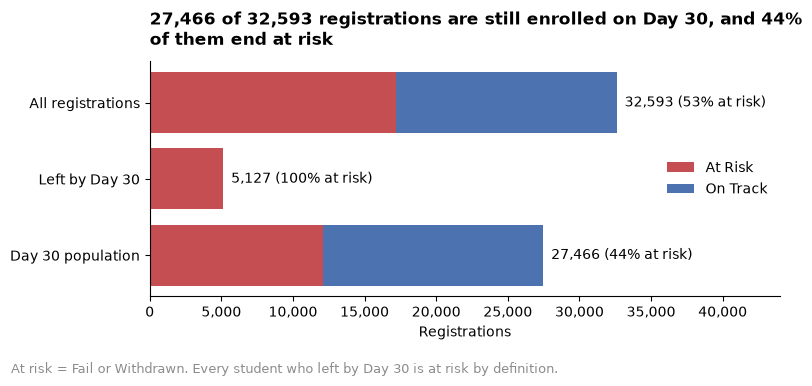

In [2]:
figs["funnel"] = plots.plot_day30_funnel(info, reg, CUTOFF_DAY)

When Withdrawn students leave, relative to the Day 30 prediction point.

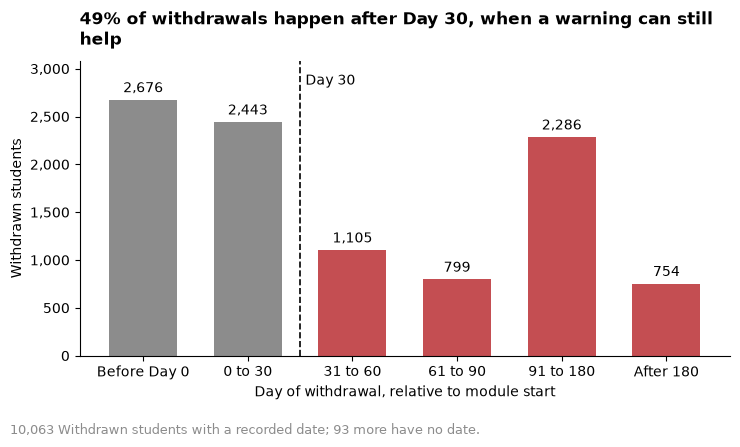

In [3]:
figs["withdrawal"] = plots.plot_withdrawal_timing(info, reg, CUTOFF_DAY)

The at-risk rate in each module of the Day 30 population, against the overall rate.

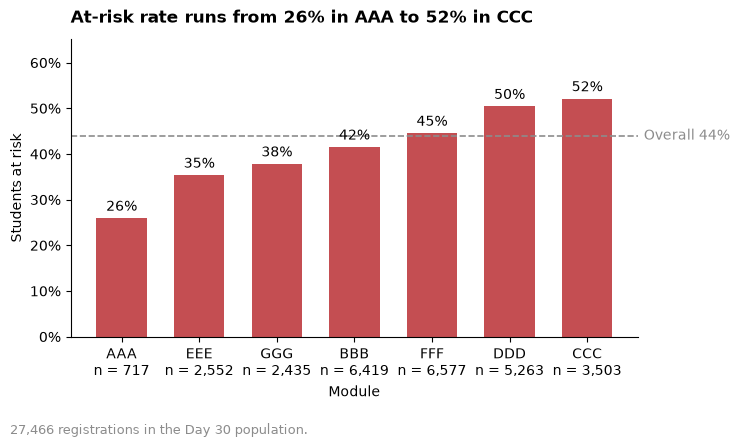

In [4]:
figs["module"] = plots.plot_at_risk_by_module(matrix)

## Engagement

The at-risk rate by the number of days a student was active up to Day 30.

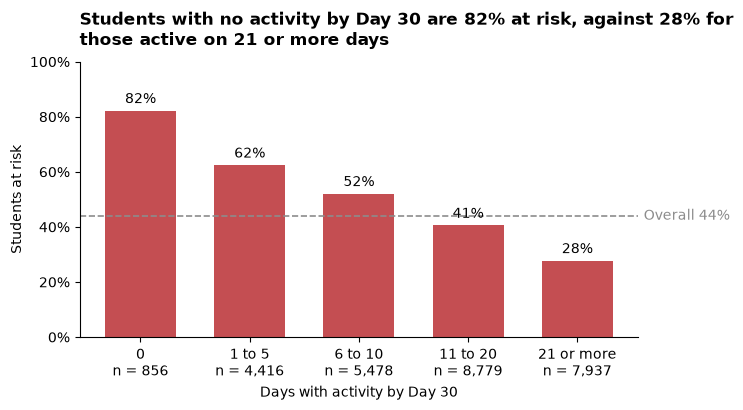

In [5]:
figs["active_days"] = plots.plot_at_risk_by_active_days(matrix, CUTOFF_DAY)

The at-risk rate by the longest run of days without any activity between Day 0 and Day 30.

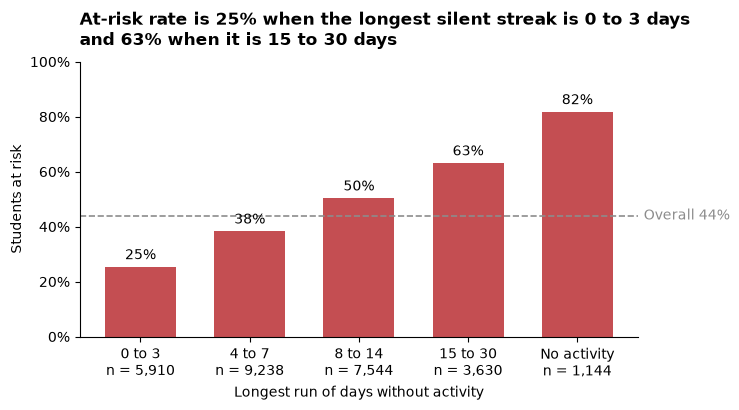

In [6]:
figs["streak"] = plots.plot_at_risk_by_inactive_streak(matrix, CUTOFF_DAY)

The at-risk rate by quarter of total clicks up to Day 30.

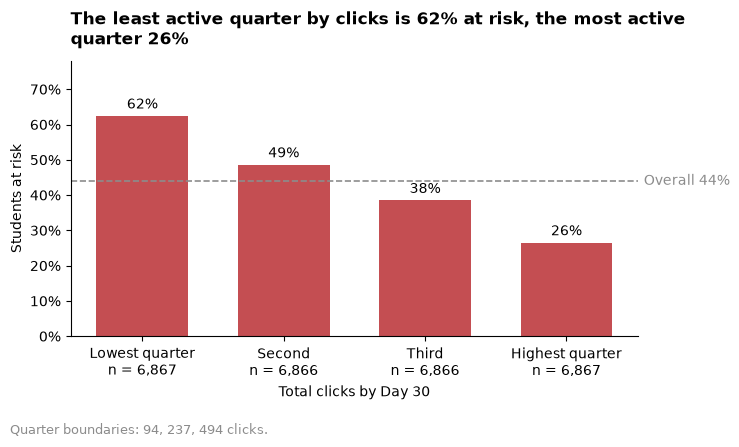

In [7]:
figs["clicks"] = plots.plot_at_risk_by_click_quartile(matrix, CUTOFF_DAY)

## Assessments

The share of students in each module who have at least one assessment score by Day 30.

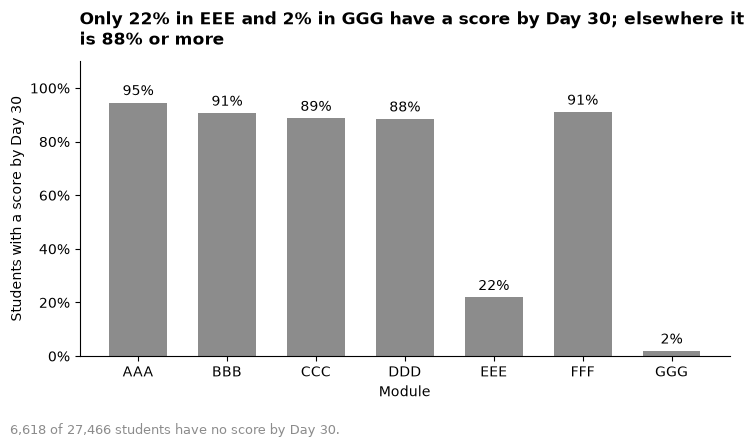

In [8]:
figs["scores"] = plots.plot_score_coverage_by_module(matrix, CUTOFF_DAY)

## Leakage check

How well clicks predict the outcome when counted up to Day 30, and when counted over the whole course.

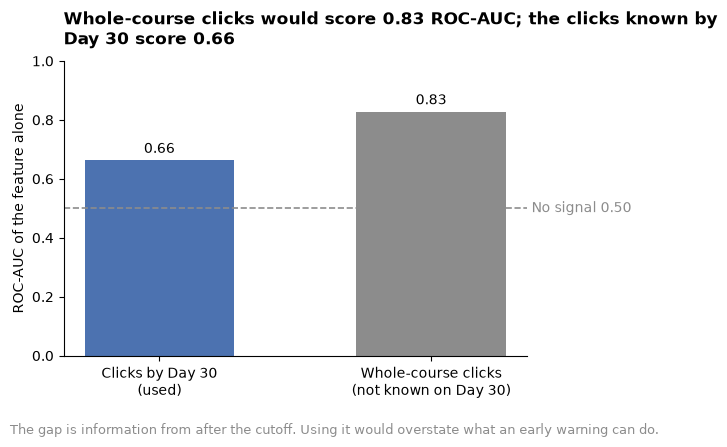

In [9]:
vle = pd.read_parquet(INTERIM_DIR / "studentVle.parquet", columns=KEY + ["sum_click"])
figs["leakage"] = plots.plot_leakage_check(matrix, vle, CUTOFF_DAY)
del vle

## Model

The baseline is a logistic regression trained on earlier presentations and validated on the latest one. It uses the feature list saved in `reports/metrics_baseline.json`.

In [10]:
features = saved_metrics["features"]
train, val = make_split(matrix)
model = train_baseline(train[features], train["at_risk"])
proba = model.predict_proba(val[features])[:, 1]
scores = evaluate(model, val[features], val["at_risk"])
same = all(abs(scores[k] - saved_metrics["validation_metrics"][k]) < 1e-6
           for k in ["recall", "precision", "pr_auc", "roc_auc"])
print(f"train rows: {len(train):,} | validation rows ({TEST_PRESENTATION}): {len(val):,} | "
      f"matches reports/metrics_baseline.json: {same}")

train rows: 16,915 | validation rows (2014J): 9,203 | matches reports/metrics_baseline.json: True


The ROC curve and the precision-recall curve on the validation presentation, with the at-risk share as the baseline.

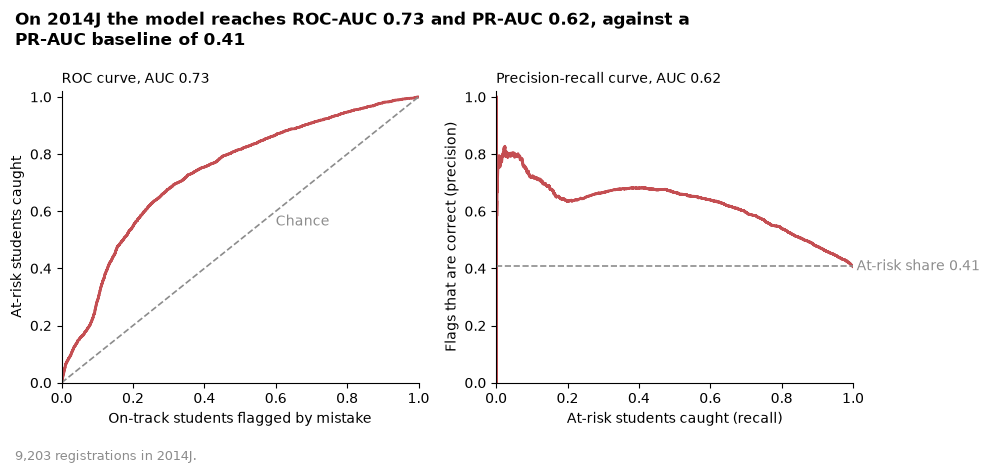

In [11]:
figs["curves"] = plots.plot_roc_pr_curves(val["at_risk"], proba, TEST_PRESENTATION)

Correct and incorrect predictions at a threshold of 0.5.

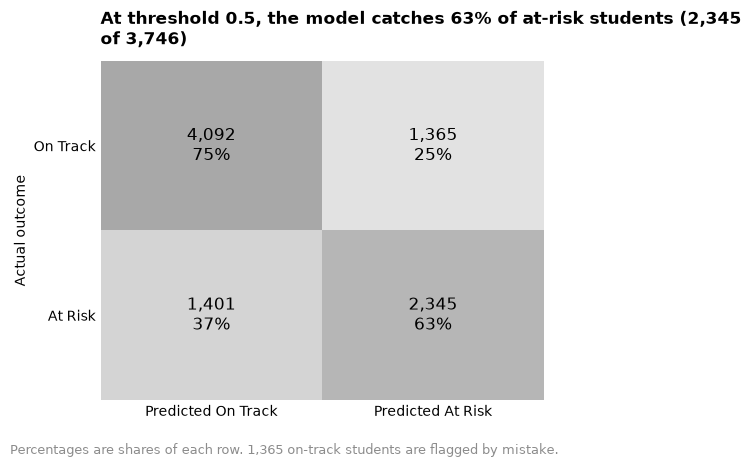

In [12]:
figs["confusion"] = plots.plot_confusion_matrix(val["at_risk"], proba, threshold=0.5)

How well the model ranks students inside each module.

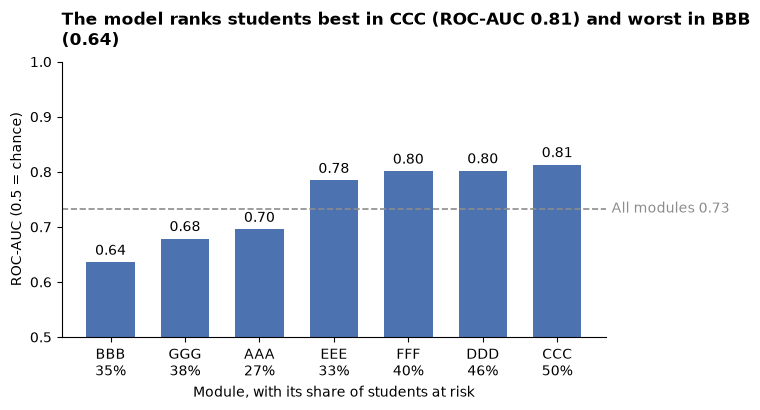

In [13]:
figs["module_auc"] = plots.plot_auc_by_module(val["code_module"], val["at_risk"], proba)

The ten inputs with the largest weight in the model, and the direction of each.

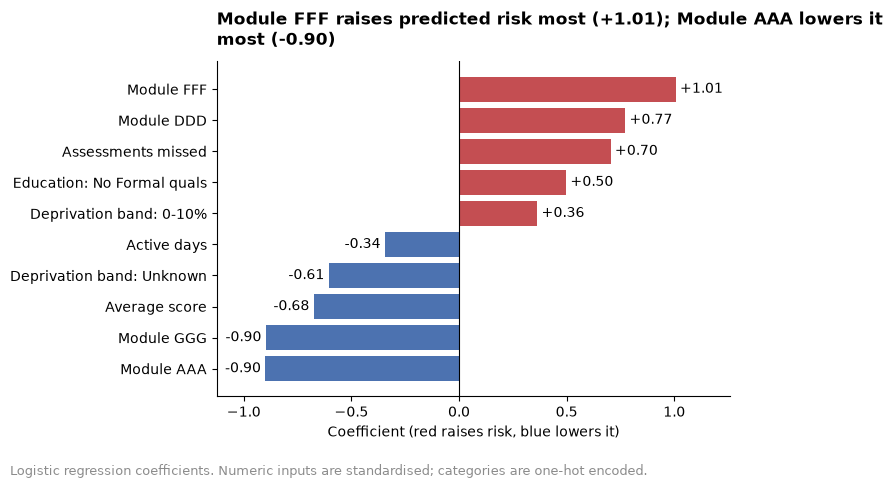

In [14]:
figs["coefficients"] = plots.plot_top_coefficients(model, n=10)

## Key findings

In [15]:
for name in ["funnel", "withdrawal", "active_days", "scores", "leakage", "curves", "confusion", "coefficients"]:
    print("-", plots.finding(figs[name]))

- 27,466 of 32,593 registrations are still enrolled on Day 30, and 44% of them end at risk
- 49% of withdrawals happen after Day 30, when a warning can still help
- Students with no activity by Day 30 are 82% at risk, against 28% for those active on 21 or more days
- Only 22% in EEE and 2% in GGG have a score by Day 30; elsewhere it is 88% or more
- Whole-course clicks would score 0.83 ROC-AUC; the clicks known by Day 30 score 0.66
- On 2014J the model reaches ROC-AUC 0.73 and PR-AUC 0.62, against a PR-AUC baseline of 0.41
- At threshold 0.5, the model catches 63% of at-risk students (2,345 of 3,746)
- Module FFF raises predicted risk most (+1.01); Module AAA lowers it most (-0.90)


## Limits

- The Day 30 population includes 16 students who registered after Day 30.
- The data records when work was submitted, not when it was marked, so a score counted here may not have been known on Day 30.
- Module membership dominates the model. Its largest weights are module indicators.
- Assessment features are almost empty for modules EEE and GGG, which have no assessment due by Day 30.